## Modeling — SMOTE + Bayesian Optimization (F2 At-Risk)

Mỗi `prediction_point` train một model riêng:
1. **SMOTE** — oversample Fail và Withdrawn, tỷ lệ tăng `(1 + x) * N_current` với `x ∈ [0.1, 0.9]`
2. **Bayesian Optimization** — tìm đồng thời: hyperparameter mô hình + SMOTE ratio + class weight
3. **Metric**: F2 score của Fail và Withdrawn (β=2, nhấn mạnh recall)
4. **Evaluate** — test với `predict()` thông thường, không threshold tuning

In [14]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED, SNAPSHOTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, fbeta_score,
)

In [15]:
data_dir = Path('../data/processed')

X_train    = pd.read_parquet(data_dir / 'X_train.parquet')
X_test     = pd.read_parquet(data_dir / 'X_test.parquet')
y_train    = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test     = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

TARGET_NAMES = ['Fail', 'Pass', 'Withdrawn']

print('X_train:', X_train.shape)
print('Features:', list(X_train.columns))
print('Snapshots:', sorted(train_meta['prediction_point'].unique()))

X_train: (142384, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Snapshots: [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(150), np.int64(180), np.int64(210), np.int64(240)]


### Helper functions

In [16]:
def get_snapshot_data(T):
    mask_tr = train_meta['prediction_point'].values == T
    mask_te = test_meta['prediction_point'].values == T
    return (
        X_train[mask_tr].reset_index(drop=True),
        X_test[mask_te].reset_index(drop=True),
        y_train[mask_tr].reset_index(drop=True),
        y_test[mask_te].reset_index(drop=True),
    )


def safe_smote(X, y, ratio_fail=0.5, ratio_withdrawn=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio ∈ [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_fail = (y_s == 0).sum()
    n_with = (y_s == 2).sum()
    target = {
        0: int((1 + ratio_fail) * n_fail),
        2: int((1 + ratio_withdrawn) * n_with),
    }
    k = max(1, min(5, n_with - 1, n_fail - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — tất cả prediction_point

**Ước tính runtime:** ~1–2 giờ (8 mốc × 30 trials × 3 folds + 1 lần retrain mỗi mốc)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (max_iter, learning_rate, max_depth, ...)
- SMOTE ratio cho Fail và Withdrawn (`smote_ratio_fail`, `smote_ratio_withdrawn` ∈ [0.1, 0.9])
- Class weight cho Fail (`w_fail` ∈ [1, 5]) và Withdrawn (`w_withdrawn` ∈ [1, 8])


############################################################
  PREDICTION POINT = 30 days
############################################################
Train: 19,988 | Test: 5,043


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4541
SMOTE  → Fail: +0.54x | Withdrawn: +0.12x
Weight → Fail: 3.94 | Withdrawn: 6.06

  T=30
              precision    recall  f1-score   support

        Fail      0.349     0.485     0.406      1274
        Pass      0.801     0.433     0.562      2804
   Withdrawn      0.276     0.503     0.357       965

    accuracy                          0.460      5043
   macro avg      0.475     0.474     0.442      5043
weighted avg      0.586     0.460     0.483      5043



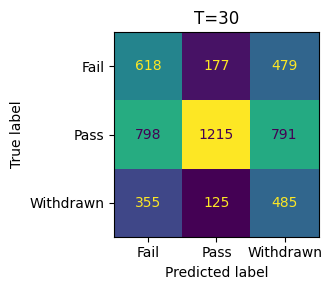


############################################################
  PREDICTION POINT = 60 days
############################################################
Train: 19,123 | Test: 4,835


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4614
SMOTE  → Fail: +0.87x | Withdrawn: +0.87x
Weight → Fail: 4.79 | Withdrawn: 7.14

  T=60
              precision    recall  f1-score   support

        Fail      0.386     0.675     0.491      1274
        Pass      0.897     0.346     0.500      2804
   Withdrawn      0.217     0.437     0.290       757

    accuracy                          0.447      4835
   macro avg      0.500     0.486     0.427      4835
weighted avg      0.656     0.447     0.465      4835



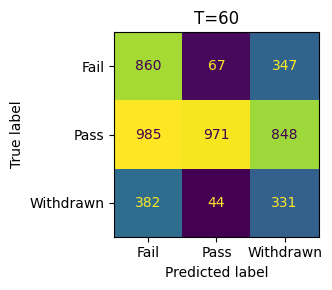


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4617
SMOTE  → Fail: +0.89x | Withdrawn: +0.87x
Weight → Fail: 4.23 | Withdrawn: 7.97

  T=90
              precision    recall  f1-score   support

        Fail      0.412     0.681     0.514      1274
        Pass      0.905     0.412     0.566      2804
   Withdrawn      0.190     0.412     0.260       602

    accuracy                          0.485      4680
   macro avg      0.503     0.501     0.447      4680
weighted avg      0.679     0.485     0.512      4680



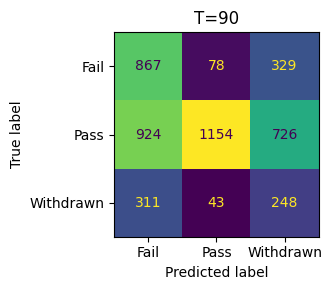


############################################################
  PREDICTION POINT = 120 days
############################################################
Train: 17,917 | Test: 4,518


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4650
SMOTE  → Fail: +0.45x | Withdrawn: +0.85x
Weight → Fail: 3.97 | Withdrawn: 7.10

  T=120
              precision    recall  f1-score   support

        Fail      0.481     0.738     0.583      1274
        Pass      0.902     0.646     0.753      2804
   Withdrawn      0.200     0.252     0.223       440

    accuracy                          0.634      4518
   macro avg      0.528     0.545     0.519      4518
weighted avg      0.715     0.634     0.653      4518



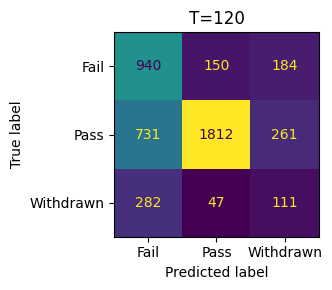


############################################################
  PREDICTION POINT = 150 days
############################################################
Train: 17,386 | Test: 4,363


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4636
SMOTE  → Fail: +0.43x | Withdrawn: +0.71x
Weight → Fail: 3.64 | Withdrawn: 7.79

  T=150
              precision    recall  f1-score   support

        Fail      0.563     0.773     0.651      1274
        Pass      0.908     0.748     0.820      2804
   Withdrawn      0.188     0.200     0.194       285

    accuracy                          0.719      4363
   macro avg      0.553     0.574     0.555      4363
weighted avg      0.760     0.719     0.730      4363



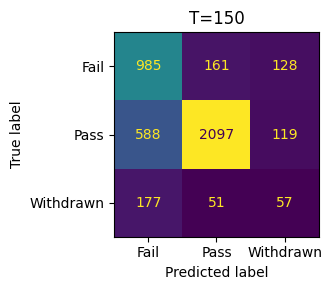


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4487
SMOTE  → Fail: +0.56x | Withdrawn: +0.70x
Weight → Fail: 1.77 | Withdrawn: 6.61

  T=180
              precision    recall  f1-score   support

        Fail      0.721     0.750     0.735      1274
        Pass      0.899     0.888     0.893      2804
   Withdrawn      0.116     0.102     0.109       137

    accuracy                          0.820      4215
   macro avg      0.579     0.580     0.579      4215
weighted avg      0.820     0.820     0.820      4215



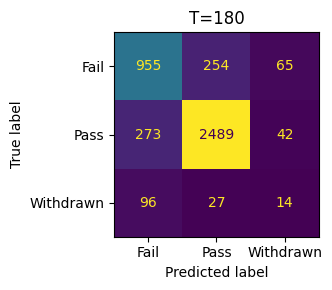


############################################################
  PREDICTION POINT = 210 days
############################################################
Train: 16,486 | Test: 4,162


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4503
SMOTE  → Fail: +0.21x | Withdrawn: +0.74x
Weight → Fail: 1.30 | Withdrawn: 7.91

  T=210
              precision    recall  f1-score   support

        Fail      0.798     0.732     0.764      1274
        Pass      0.898     0.926     0.912      2804
   Withdrawn      0.146     0.179     0.160        84

    accuracy                          0.852      4162
   macro avg      0.614     0.612     0.612      4162
weighted avg      0.852     0.852     0.851      4162



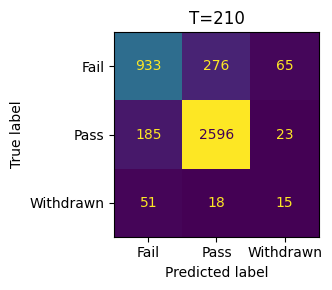


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.5177
SMOTE  → Fail: +0.60x | Withdrawn: +0.85x
Weight → Fail: 1.04 | Withdrawn: 4.83

  T=240
              precision    recall  f1-score   support

        Fail      0.858     0.766     0.810      1274
        Pass      0.905     0.946     0.925      2804
   Withdrawn      0.222     0.375     0.279        16

    accuracy                          0.888      4094
   macro avg      0.662     0.696     0.671      4094
weighted avg      0.888     0.888     0.887      4094



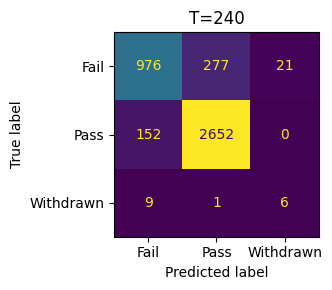


--- Tổng hợp ---


,prediction_point,accuracy,recall_fail,recall_pass,recall_withdrawn,macro_recall,precision_fail,precision_withdrawn,f2_at_risk
0,30,0.4596,0.4851,0.4333,0.5026,0.4737,0.3490,0.2764,0.4409
1,60,0.4472,0.6750,0.3463,0.4373,0.4862,0.3862,0.2169,0.4753
2,90,0.4848,0.6805,0.4116,0.4120,0.5013,0.4125,0.1903,0.4682
3,120,0.6337,0.7378,0.6462,0.2523,0.5454,0.4813,0.1996,0.4532
4,150,0.7195,0.7732,0.7479,0.2000,0.5737,0.5629,0.1875,0.4584
5,180,0.8204,0.7496,0.8877,0.1022,0.5798,0.7213,0.1157,0.4242
6,210,0.8515,0.7323,0.9258,0.1786,0.6122,0.7981,0.1456,0.4577
7,240,0.8876,0.7661,0.9458,0.3750,0.6956,0.8584,0.2222,0.5563


In [17]:
models  = {}
results = []

for T in SNAPSHOTS:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'max_iter':          trial.suggest_int('max_iter', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
            'random_state':      RANDOM_SEED,
        }
        r_fail = trial.suggest_float('smote_ratio_fail', 0.1, 0.9)
        r_with = trial.suggest_float('smote_ratio_withdrawn', 0.1, 0.9)
        w_fail = trial.suggest_float('w_fail', 1.0, 5.0)
        w_with = trial.suggest_float('w_withdrawn', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            Xf_sm, yf_sm = safe_smote(Xf_tr, yf_tr, r_fail, r_with)
            m = HistGradientBoostingClassifier(
                **params,
                class_weight={0: w_fail, 1: 1.0, 2: w_with},
            )
            m.fit(Xf_sm, yf_sm)

            score = fbeta_score(
                yf_val, m.predict(Xf_val),
                beta=2, average='macro', labels=[0, 2], zero_division=0,
            )
            fold_scores.append(score)
        return np.mean(fold_scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best = study.best_params
    print(f'Best F2 CV: {study.best_value:.4f}')
    print(f'SMOTE  → Fail: +{best["smote_ratio_fail"]:.2f}x | Withdrawn: +{best["smote_ratio_withdrawn"]:.2f}x')
    print(f'Weight → Fail: {best["w_fail"]:.2f} | Withdrawn: {best["w_withdrawn"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    X_sm, y_sm = safe_smote(
        X_tr, y_tr,
        ratio_fail=best['smote_ratio_fail'],
        ratio_withdrawn=best['smote_ratio_withdrawn'],
    )
    model_final = HistGradientBoostingClassifier(
        max_iter=best['max_iter'],
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        l2_regularization=best['l2_regularization'],
        max_leaf_nodes=best['max_leaf_nodes'],
        class_weight={0: best['w_fail'], 1: 1.0, 2: best['w_withdrawn']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te))
    evaluate_full(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    results.append({
        'prediction_point':    T,
        'accuracy':            round(accuracy_score(y_te, y_pred), 4),
        'recall_fail':         round(recalls[0], 4),
        'recall_pass':         round(recalls[1], 4),
        'recall_withdrawn':    round(recalls[2], 4),
        'macro_recall':        round(recalls.mean(), 4),
        'precision_fail':      round(precisions[0], 4),
        'precision_withdrawn': round(precisions[2], 4),
        'f2_at_risk':          round(fbeta_score(y_te, y_pred, beta=2, average='macro',
                                                  labels=[0, 2], zero_division=0), 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df

---

## Feature Importance — Permutation Importance

Tính permutation importance trên test set cho từng `prediction_point`, dùng F2 at-risk (Fail+Withdrawn, β=2) làm scoring để đo đúng mức độ ảnh hưởng tới mục tiêu chính.

In [18]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

f2_at_risk_scorer = make_scorer(
    fbeta_score, beta=2, average='macro', labels=[0, 2], zero_division=0,
)

importance_records = []

for T in SNAPSHOTS:
    _, X_te_raw, _, y_te = get_snapshot_data(T)
    X_te = X_te_raw.fillna(0)

    result = permutation_importance(
        models[T], X_te, y_te,
        scoring=f2_at_risk_scorer,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    for feat, mean_imp, std_imp in zip(X_te.columns, result.importances_mean, result.importances_std):
        importance_records.append({
            'prediction_point': T,
            'feature': feat,
            'importance_mean': mean_imp,
            'importance_std': std_imp,
        })

importance_df = pd.DataFrame(importance_records)
importance_df

,prediction_point,feature,importance_mean,importance_std
0,30,highest_education,-0.000039,0.002027
1,30,disability,-0.001309,0.002092
2,30,num_of_prev_attempts,0.005747,0.004840
3,30,studied_credits,0.010114,0.004794
4,30,total_clicks_filled,0.004837,0.004502
...,...,...,...,...
115,240,num_failed_filled,0.001220,0.009166
116,240,avg_days_early_filled,0.012536,0.016609
117,240,no_submission_despite_due,0.110280,0.016416
118,240,imd_band_filled,0.000953,0.002771


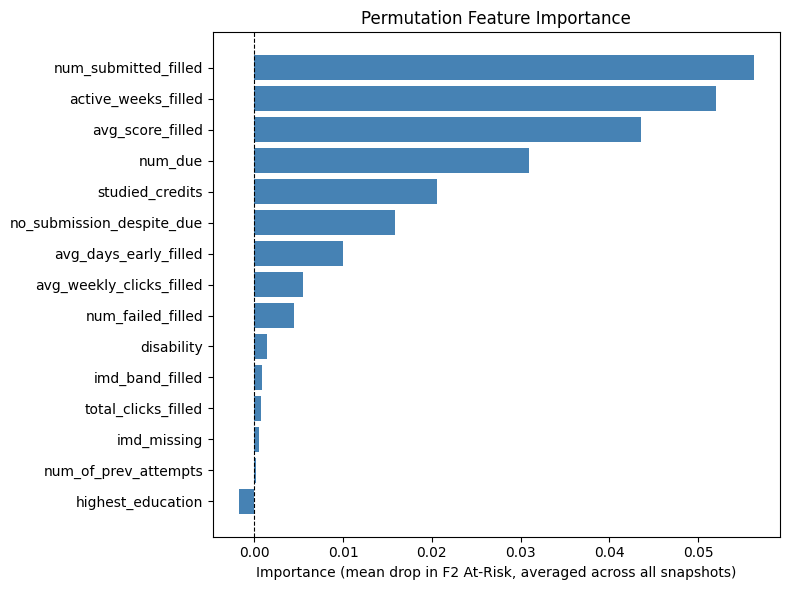

In [19]:
avg_importance = (
    importance_df.groupby('feature')['importance_mean']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(avg_importance.index, avg_importance.values, color='steelblue')
ax.set_xlabel('Importance (mean drop in F2 At-Risk, averaged across all snapshots)')
ax.set_title('Permutation Feature Importance')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()